In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from pmdarima.arima import ndiffs

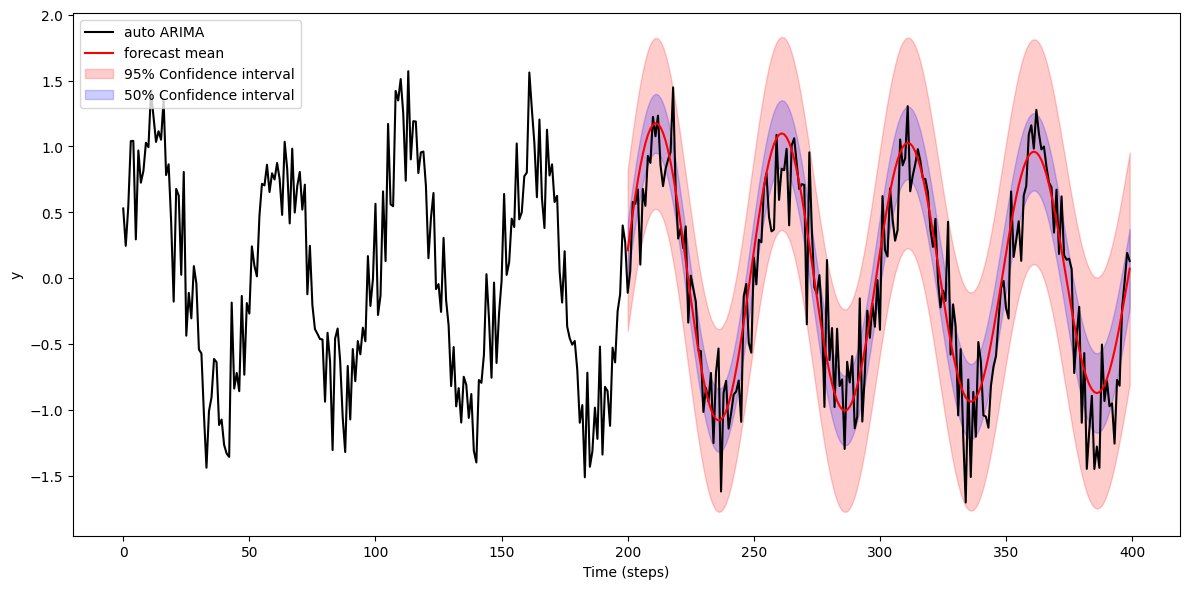

In [110]:
np.random.seed(0)

n = 400
t = np.arange(n)

signal = np.sin(2*np.pi*t/50)+0.3*np.random.randn(n)

data = pd.Series(signal)

split = 200
kpss_diffs = ndiffs(data.iloc[:split], alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(data.iloc[:split], alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)

model = auto_arima(
    data.iloc[:split],
    seasonal=True,
    suppress_warnings=True
)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()


In [111]:
from external.api_repo.generators import *
from external.api_repo.utils import *

In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
boltzman= 1.38e-11
zeta = 2.24e-9

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 30
time_step = 4e-3

barrier_height=0.9e-8
left_well=3
right_well=-3
x0_mean=0
tilt=0#1e-12#2e-50
num_of_simulations=8


x,dwt=double_wells_generator(total_time=total_time, zeta=zeta,T=T,time_step=time_step,boltzmann=boltzman,right_well=right_well,left_well=left_well,
                          barrier_height=barrier_height,x0_mean=x0_mean,device=device  ,num_of_simulations=num_of_simulations,tilt=tilt)

In [113]:
x_single = x[0]
data = pd.Series(x_single.detach().cpu().numpy())

In [114]:
np.random.seed(0)

split = 3000
train_data=data.iloc[:split]

kpss_diffs = ndiffs(train_data, alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(train_data, alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-4210.149, Time=2.30 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-4202.796, Time=0.27 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-4206.961, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-4207.384, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-4204.659, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-4210.438, Time=1.43 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-4208.314, Time=0.52 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-4207.267, Time=1.36 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-4208.876, Time=2.33 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-4208.202, Time=0.62 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-4210.817, Time=2.75 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-4208.504, Time=0.29 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-4209.221, Time=2.52 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-4208.458, Time=0.45 sec
 ARIMA(3,1,2)(0,0,0

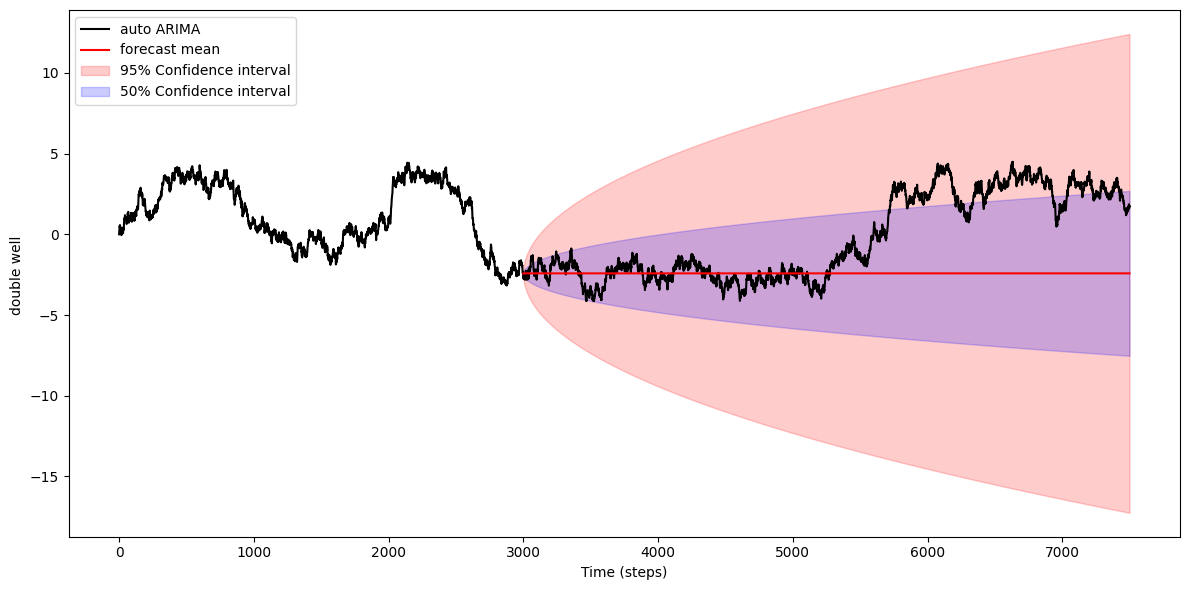

In [115]:
model = auto_arima(
    train_data,
    seasonal=True,
    m=1, #searon length
    d=n_diffs,
    suppress_warnings=True, error_action="ignore",
    max_order=None, trace=True
)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

#num_trajs=4
#for _ in range(num_trajs):
#    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-4210.149, Time=2.60 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-4202.796, Time=0.26 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-4206.961, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-4207.384, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-4204.659, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-4210.438, Time=1.21 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-4208.314, Time=0.33 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-4207.267, Time=0.79 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-4208.876, Time=1.69 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-4208.202, Time=0.82 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-4210.817, Time=1.93 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-4208.504, Time=0.20 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-4209.221, Time=2.41 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-4208.458, Time=0.35 sec
 ARIMA(3,1,2)(0,0,0

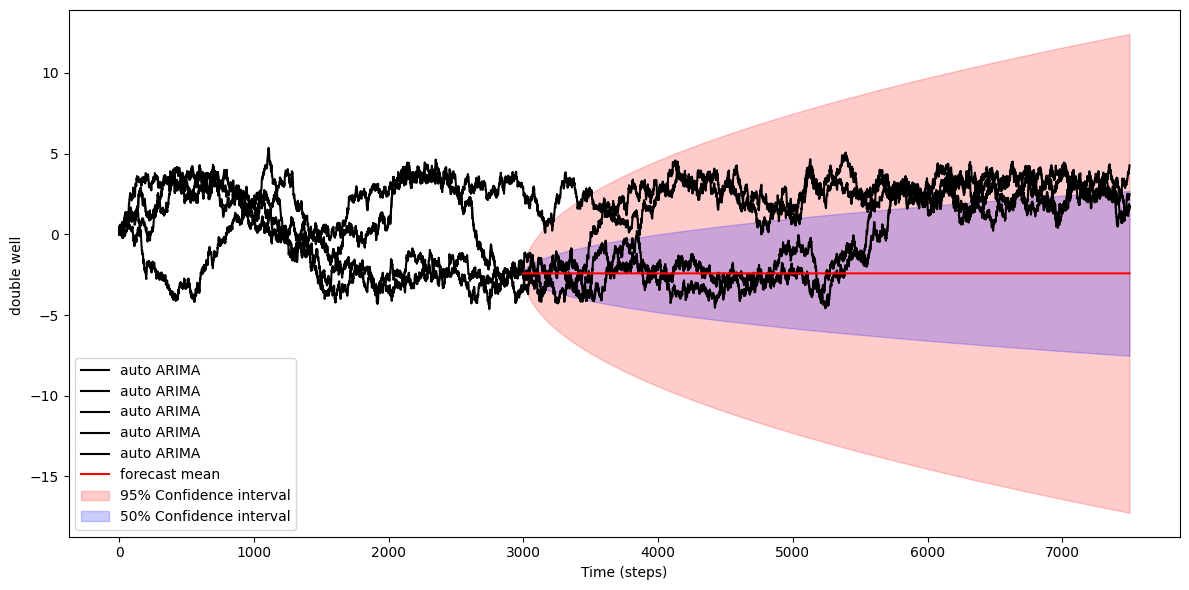

In [118]:
model = auto_arima(
    train_data,
    seasonal=True,
    m=1, #searon length
    d=n_diffs,
    suppress_warnings=True, error_action="ignore",
    max_order=None, trace=True
)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

num_trajs=4
for _ in range(num_trajs):
    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black", label="auto ARIMA")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()


Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=inf, Time=0.95 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=232.048, Time=0.03 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=208.165, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=204.575, Time=0.06 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=201.149, Time=0.05 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=200.790, Time=0.07 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=200.226, Time=0.04 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=199.479, Time=0.06 sec
 ARIMA(4,2,0)(0,0,0)[0]             : AIC=200.847, Time=0.05 sec
 ARIMA(3,2,1)(0,0,0)[0]             : AIC=201.217, Time=0.15 sec
 ARIMA(4,2,1)(0,0,0)[0]             : AIC=199.795, Time=0.14 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=201.474, Time=0.08 sec

Best model:  ARIMA(3,2,0)(0,0,0)[0]          
Total fit time: 1.717 seconds


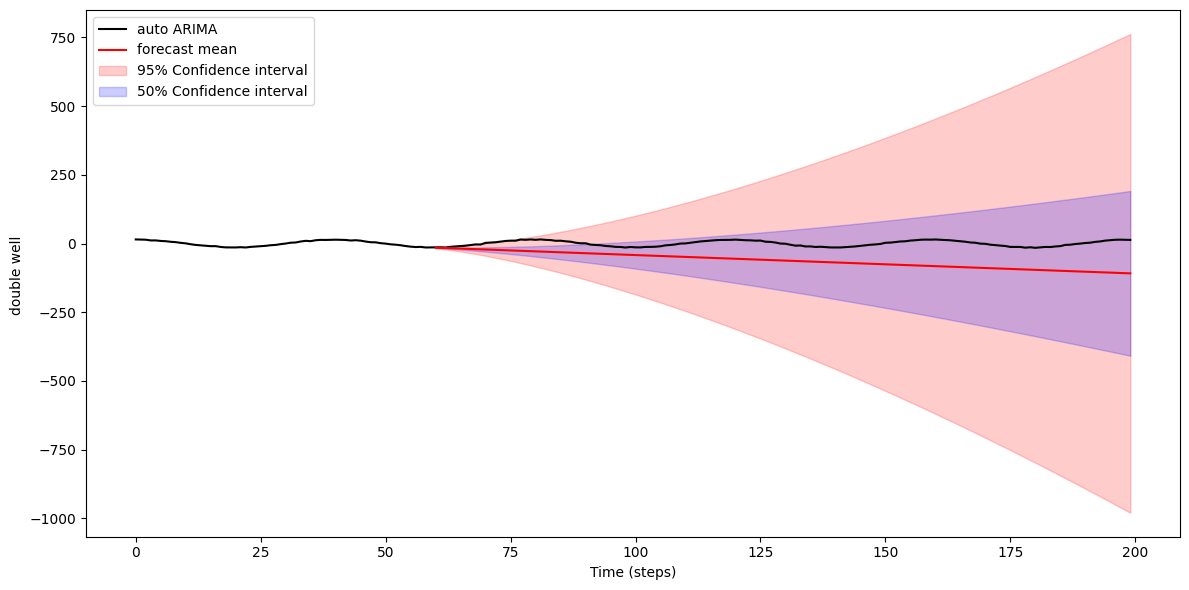

In [ ]:
singal=14*np.cos(np.linspace(0, 20*np.pi, 200))+0.8*np.random.randn(200)
data = pd.Series(singal)
split=60
train_data = data.iloc[:split]

kpss_diffs = ndiffs(train_data, alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(train_data, alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)

model = auto_arima(
    train_data,
    seasonal=True,
    d=n_diffs,
    suppress_warnings=True, error_action="ignore",
    max_order=None, trace=True
)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

#num_trajs=4
#for _ in range(num_trajs):
#    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black", label="auto ARIMA")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()
